Компания предоставила вам обучающую и тестовую выборки за последние несколько месяцев. В данных содержатся следующие поля:

- client_id — уникальный идентификатор клиента;
- reject_count — количество отменённых заказов за всё время;
- confirm_count — количество подтверждённых заказов за всё время;
- last_summ — стоимость последнего заказа клиента;
- summ_ — сумма заказов, полученная от клиента за всё время;
- count_position — число позиций в последнем заказе;
- target — целевая переменная — заказ отменён (1), заказ выполнен (0).

Таким образом, у вас есть классическая бинарная задача классификации, и для её решения стоит использовать метод опорных векторов (SVM).

In [1]:
!pip install -q scikit-learn numpy pandas seaborn

In [13]:
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report

In [3]:
# -------------------------------
# Шаг 1: Загрузка обучающей выборки
# Загружаем данные и изучаем их структуру
train = pd.read_csv('https://code.s3.yandex.net/datasets/orders_seafood_new.csv')
print("Размер обучающей выборки:", train.shape)
print("Первые 5 строк:")
print(train.head(5))

# -------------------------------
# Шаг 2: Загрузка тестовой выборки
# Загружаем финальный тестовый набор и смотрим структуру
test = pd.read_csv('https://code.s3.yandex.net/datasets/orders_seafood_new_final_test.csv')
print("Размер тестовой выборки:", test.shape)
print("Первые 5 строк:")
print(test.head(5))

Размер обучающей выборки: (550, 7)
Первые 5 строк:
   client_id  reject_count  confirm_count  last_summ    summ_  count_position  \
0     180224             8            173   136444.7  18747.0              11   
1     118790             6             10    50043.7  26028.1              16   
2     143366             7             17   190715.9  32471.4              19   
3     135176             5             23   140677.7  39759.9              18   
4     135175             2             19    92773.0  17608.3              10   

   target  
0       0  
1       1  
2       1  
3       1  
4       1  
Размер тестовой выборки: (200, 7)
Первые 5 строк:
   client_id  reject_count  confirm_count  last_summ    summ_  count_position  \
0      81922             4             17    96886.1  26557.8              17   
1      90119             7            174   184062.9  25251.0              17   
2      28679             3             20   125647.1  36458.7              19   
3      98311    

In [4]:
import pandas as pd

# Проверим типы данных
print("\nТипы признаков в train:")
print(train.dtypes)

# Проверим наличие пропусков
print("\nКоличество пропусков в train:")
print(train.isnull().sum())

# Проверим типы данных
print("\nТипы признаков в test:")
print(test.dtypes)

# Проверим наличие пропусков
print("\nКоличество пропусков в test:")
print(test.isnull().sum())


Типы признаков в train:
client_id           int64
reject_count        int64
confirm_count       int64
last_summ         float64
summ_             float64
count_position      int64
target              int64
dtype: object

Количество пропусков в train:
client_id         0
reject_count      0
confirm_count     0
last_summ         0
summ_             0
count_position    0
target            0
dtype: int64

Типы признаков в test:
client_id           int64
reject_count        int64
confirm_count       int64
last_summ         float64
summ_             float64
count_position      int64
target              int64
dtype: object

Количество пропусков в test:
client_id         0
reject_count      0
confirm_count     0
last_summ         0
summ_             0
count_position    0
target            0
dtype: int64


In [5]:
# Выбираем числовые признаки
num_features = ["reject_count", "confirm_count", "last_summ", "summ_", "count_position"]

for col in num_features:
    print(f"\nПризнак: {col}")
    desc = train[col].describe()

    mean = desc["mean"]
    std = desc["std"]

    # Считаем выбросы как значения, которые выходят за пределы 3 стандартных отклонений
    outliers = train[(train[col] < mean - 3*std) | (train[col] > mean + 3*std)]
    print(f"Количество выбросов (>|3σ|): {len(outliers)}")


Признак: reject_count
Количество выбросов (>|3σ|): 7

Признак: confirm_count
Количество выбросов (>|3σ|): 31

Признак: last_summ
Количество выбросов (>|3σ|): 0

Признак: summ_
Количество выбросов (>|3σ|): 11

Признак: count_position
Количество выбросов (>|3σ|): 14


<Axes: xlabel='target', ylabel='count'>

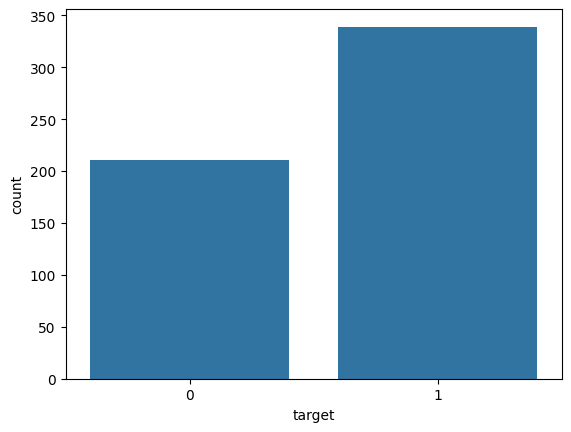

In [6]:
sns.countplot(train, x='target')

In [7]:
X_train = train.drop(columns=["client_id", "target"])
y_train = train["target"]

X_test = test.drop(columns=["client_id", "target"])
y_test = test["target"]

# Проверяем формы
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (550, 5)
y_train: (550,)
X_test: (200, 5)
y_test: (200,)


In [8]:
from sklearn.preprocessing import StandardScaler

# Создаём объект StandardScaler
scaler = StandardScaler()

# Обучаем на train и преобразуем train и test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Проверяем форму
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (550, 5)
X_test_scaled: (200, 5)


In [11]:
# Создаём Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),       # Масштабирование признаков
    ('svm', SVC(kernel='linear', random_state=42))  # SVM с линейным ядром
])

# Создайте стратифицированное k-fold разбиение (5 фолдов)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Напишите ваш код здесь

# Список метрик для оценки модели
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Задайте кросс-валидацию
cv_results = cross_validate(
    pipeline , # Пайплайн
    X_train , # Признаки
    y_train, # Целевая переменная
    cv=skf , # объект StratifiedKFold
    scoring=scoring  # Список метрик
)

# Извлекаем средние значения метрик
results_means = {
    "accuracy": cv_results["test_accuracy"].mean(),
    "precision": cv_results["test_precision"].mean(),
    "recall": cv_results["test_recall"].mean(),
    "f1": cv_results["test_f1"].mean(),
}

print("Результаты модели на кросс-валидации (средние значения):")
print("-" * 50)
print(f"accuracy: {results_means['accuracy']:.3f}")
print(f"precision:   {results_means['precision']:.3f}")
print(f"recall: {results_means['recall']:.3f}")
print(f"f1:   {results_means['f1']:.3f}")

# Извлекаем стандартные отклонения метрик
results_std = {
    "accuracy": cv_results["test_accuracy"].std(),
    "precision": cv_results["test_precision"].std(),
    "recall": cv_results["test_recall"].std(),
    "f1": cv_results["test_f1"].std(),
}

print("Результаты модели на кросс-валидации (стандартные отклонения):")
print("-" * 50)
print(f"accuracy: {results_std['accuracy']:.3f}")
print(f"precision:   {results_std['precision']:.3f}")
print(f"recall: {results_std['recall']:.3f}")
print(f"f1:   {results_std['f1']:.3f}")

Результаты модели на кросс-валидации (средние значения):
--------------------------------------------------
accuracy: 0.582
precision:   0.604
recall: 0.906
f1:   0.724
Результаты модели на кросс-валидации (стандартные отклонения):
--------------------------------------------------
accuracy: 0.092
precision:   0.048
recall: 0.138
f1:   0.079


In [15]:
# Обучите модель на всей обучающей выборке
pipeline.fit(X_train, y_train)

# Получите предсказания на тесте
y_pred = pipeline.predict(X_test)

# Выведите подробный отчёт по метрикам
report = classification_report(y_test, y_pred, digits=3)# Напишите ваш код здесь
print(report)

              precision    recall  f1-score   support

           0      0.636     0.215     0.322        65
           1      0.713     0.941     0.812       135

    accuracy                          0.705       200
   macro avg      0.675     0.578     0.567       200
weighted avg      0.688     0.705     0.652       200

